In [12]:
import os
import base64
from io import BytesIO

import pandas as pd
import numpy as np

from PIL import Image
from IPython.display import HTML, display

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Catálogo de lentes y catálogo morfológico

* **Strong Lens Candidate Catalogue** (https://zenodo.org/records/15025832)
  * Most (250 grade A, 247 grade B) candidates are from the discovery_engine subset. These were identified by our main search and follow the selection reported in our papers.
  * We also include 56 grade A and 19 grade B candidates identified by Galaxy Zoo Euclid volunteers as part of a campaign to measure visual morphology; these are outside of the Q1 footprint and have a different selection function.
  * Finally, we include 3 grade A candidates missed by our search but identified serendiptously. These are inside Q1.

* **First visual morphology catalogue** (https://zenodo.org/records/15106473)

In [13]:
LENS_PATH = "/content/drive/MyDrive/catalogues/strong_lensing_catalogue/q1_discovery_engine_lens_catalog.csv"
MORPH_PATH = "/content/drive/MyDrive/catalogues/morphology_catalogue/morphology_catalogue.parquet"
CUTOUT_BASE = "/content/drive/MyDrive/catalogues/morphology_catalogue/cutouts_jpg_gz_arcsinh_vis_only"

lens_df = pd.read_csv(
    LENS_PATH,
    dtype={"object_id": "string"}
)

morph_df = pd.read_parquet(MORPH_PATH)

morph_df = morph_df.copy()
morph_df["object_id"] = morph_df["object_id"].astype("string")
morph_df["id_str"] = morph_df["id_str"].astype("string")

print(lens_df.shape)
print(morph_df.shape)

(2584, 13)
(380111, 74)


## Comprobamos si los objetos están en el catálogo de lentes

* Q1_R1_102159490_2745640369664151739
* Q1_R1_102160058_2686872296674105661


In [25]:
query_ids = [
    "2745640369664151739",
    "2686872296674105661"
]

lens_set = set(lens_df["object_id"])

for oid in query_ids:
    if oid in lens_set:
        print(f"{oid} → ✅ ES lente")
    else:
        print(f"{oid} → ❌ NO catalogado como lente")

2745640369664151739 → ❌ NO catalogado como lente
2686872296674105661 → ❌ NO catalogado como lente


## Pintar objetos del catálogo morfológico por object_id

Objetos seleccionados: 2
Objetos encontrados en morphology: 2


preview,object_id,id_str
,2745640369664151739,Q1_R1_102159490_2745640369664151739
,2686872296674105661,Q1_R1_102160058_2686872296674105661

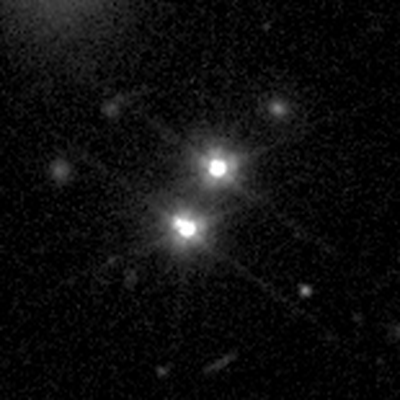
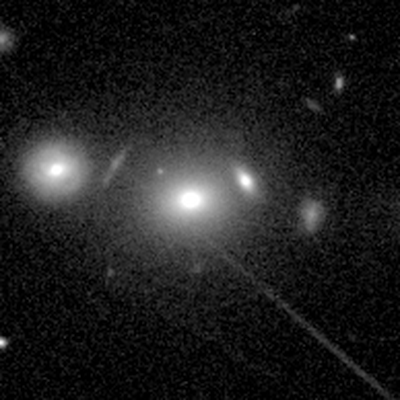

In [24]:
target_object_ids = pd.Series(query_ids, dtype="string").astype(str).tolist()

def image_to_base64_html(image_path, max_size=(180, 180), fixed_size=None):
    if image_path is None or not os.path.exists(image_path):
        return "N/A"

    try:
        img = Image.open(image_path)

        if fixed_size:
            img = img.resize(fixed_size, Image.Resampling.LANCZOS)
        else:
            img.thumbnail(max_size)

        buffer = BytesIO()
        img.save(buffer, format="PNG")
        encoded = base64.b64encode(buffer.getvalue()).decode("utf-8")

        if fixed_size:
            return (
                f'<img src="data:image/png;base64,{encoded}" '
                f'style="width:{fixed_size[0]}px; height:{fixed_size[1]}px;">'
            )
        else:
            return (
                f'<img src="data:image/png;base64,{encoded}" '
                f'style="max-width:{max_size[0]}px; max-height:{max_size[1]}px;">'
            )

    except Exception as e:
        return f"ERROR: {e}"


def add_jpg_path_from_id_str(df, cutout_base):
    """
    Reconstruye la ruta JPEG usando el formato:

    id_str:
      Q1_R1_102160058_2686872296674105661

    ruta:
      CUTOUT_BASE/102160058/102160058_2686872296674105661_gz_arcsinh_vis_only.jpg

    Para object_id negativos, el filename usa NEG en lugar de '-'.
    """
    df = df.copy()

    parts = df["id_str"].astype(str).str.rsplit("_", n=2, expand=True)

    df["release_name"] = parts[0]
    df["tile_index"] = parts[1].astype("string")
    df["object_id_from_id_str"] = parts[2].astype("string")

    object_id_for_filename = df["object_id_from_id_str"].str.replace("-", "NEG", regex=False)

    df["jpg_filename"] = (
        df["tile_index"].astype(str)
        + "_"
        + object_id_for_filename.astype(str)
        + "_gz_arcsinh_vis_only.jpg"
    )

    df["jpg_path"] = (
        cutout_base
        + "/"
        + df["tile_index"].astype(str)
        + "/"
        + df["jpg_filename"].astype(str)
    )

    return df

# ------------------------------------------------------------
# FILTRAR OBJETOS
# ------------------------------------------------------------

selected_df = morph_df[
    morph_df["object_id"].astype(str).isin(target_object_ids)
].copy()

missing_ids = sorted(set(target_object_ids) - set(selected_df["object_id"].astype(str)))

print("Objetos seleccionados:", len(target_object_ids))
print("Objetos encontrados en morphology:", len(selected_df))

if missing_ids:
    print("No encontrados en morphology:")
    for oid in missing_ids:
        print(" -", oid)

if selected_df.empty:
    raise ValueError("No se encontró ningún object_id en el catálogo morfológico.")

# ------------------------------------------------------------
# CONSTRUIR RUTAS Y PREVIEWS
# ------------------------------------------------------------

selected_img_df = add_jpg_path_from_id_str(selected_df, CUTOUT_BASE)

selected_img_df["image_exists"] = selected_img_df["jpg_path"].apply(os.path.exists)

selected_img_df["preview"] = selected_img_df["jpg_path"].apply(
    lambda x: image_to_base64_html(x, fixed_size=(400, 400))
)

# ------------------------------------------------------------
# MOSTRAR TABLA
# ------------------------------------------------------------

cols_to_show = [
    "preview",
    "object_id",
    "id_str",
    #"jpg_path",
]

cols_to_show = [c for c in cols_to_show if c in selected_img_df.columns]

display(
    HTML(
        selected_img_df[cols_to_show]
        .to_html(escape=False, index=False)
    )
)